<>:4: SyntaxWarning: invalid escape sequence '\Y'
<>:4: SyntaxWarning: invalid escape sequence '\Y'
C:\Users\lochl\AppData\Local\Temp\ipykernel_10872\152882632.py:4: SyntaxWarning: invalid escape sequence '\Y'
  FILE = "C:\Year 2\DataFest\Datafest-2026\data\energie-en-broeikasgassen.xlsx"


Available sheets: ['Voorblad', 'Inhoud', 'Toelichting', 'Tabel1aAanbodWinning&Invoer', 'Tabel1bAanbodUitvoer&Verbruik', 'Tabel2aOmzettingsSaldo', 'Tabel2bDistributieverliezen', 'Tabel2cEigenVerbr.EnergieSector', 'Tabel2dFinaalVerbruik', 'Tabel3aNietEnergetischgebruik', 'Tabel3bFinaalEnergieverbruik', 'Tabel4aFinaalVerbruikElek', 'Tabel4bFinaalVerbruikMobiliteit', 'Tabel4cFinaalVerbruikWarmte', 'Tabel5AanbodElektriciteit', 'Tabel6aEmissieNaarSector', 'Tabel6bEmissieEnergiedrager', 'Tabel6cEmissieInterTransport']

--- Emissies totaal (laatste 10 jaar) ---
 Jaar  Emissie (Mton CO2-equivalenten)  Reductie t.o.v. 1990 (%)
 2015                            199.9                     -12.1
 2016                            200.2                     -12.0
 2017                            196.7                     -13.5
 2018                            191.4                     -15.9
 2019                            185.2                     -18.6
 2020                            168.3            

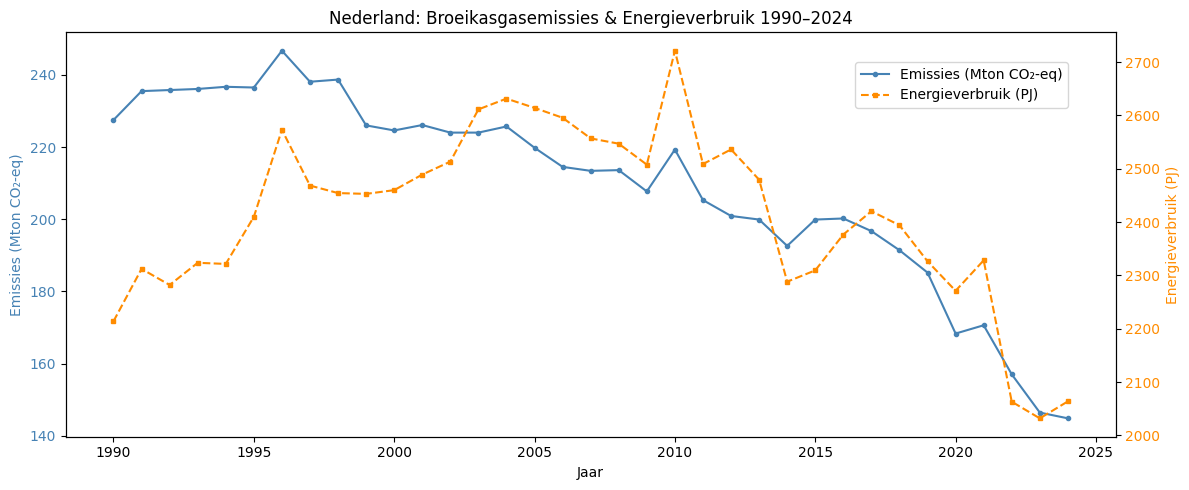

Plot saved to emissies_verbruik.png
Results saved to output.xlsx


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

FILE = "C:\Year 2\DataFest\Datafest-2026\data\energie-en-broeikasgassen.xlsx"

# ------------------------------------------------------------------
# Load the workbook
# ------------------------------------------------------------------
xl = pd.ExcelFile(FILE)
print("Available sheets:", xl.sheet_names)

# ------------------------------------------------------------------
# Sheet: Tabel6aEmissieNaarSector
# Columns: Jaar, Broeikasgas, SectorKlimaatAkkoord, Emissie (Mton CO2-equivalenten)
# ------------------------------------------------------------------
df_emissies = pd.read_excel(xl, sheet_name="Tabel6aEmissieNaarSector")

# Total greenhouse gases across all sectors per year
totaal = df_emissies[
    (df_emissies["Broeikasgas"] == "TotaalBroeikasgassen") &
    (df_emissies["SectorKlimaatAkkoord"] == "TotaalSectoren")
].copy()

# Emissions by sector per year (pivot)
pivot_sectoren = df_emissies[
    df_emissies["Broeikasgas"] == "TotaalBroeikasgassen"
].pivot_table(
    index="Jaar",
    columns="SectorKlimaatAkkoord",
    values="Emissie (Mton CO2-equivalenten)"
)

# ------------------------------------------------------------------
# Sheet: Tabel2dFinaalVerbruik
# Columns: Jaar, Balanspost, Energiedrager, Waarde in PJ
# ------------------------------------------------------------------
df_verbruik = pd.read_excel(xl, sheet_name="Tabel2dFinaalVerbruik")

# Total final energy consumption per year
totaal_verbruik = df_verbruik[
    df_verbruik["Energiedrager"] == "Totaal energiedragers"
].copy()

# ------------------------------------------------------------------
# Sheet: Tabel6bEmissieEnergiedrager
# Columns: Jaar, Energiedrager, Emissie (Mton CO2-equivalenten)
# ------------------------------------------------------------------
df_emissie_drager = pd.read_excel(xl, sheet_name="Tabel6bEmissieEnergiedrager")

# Emissions by energy carrier, summed over all years
# Note: this sheet uses "Emissie (Mton)", not "Emissie (Mton CO2-equivalenten)"
emissie_per_drager = (
    df_emissie_drager
    .groupby("Energiedrager")["Emissie (Mton)"]
    .sum()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------------
# Trend: % reduction in emissions since 1990
# ------------------------------------------------------------------
baseline = totaal.loc[totaal["Jaar"] == 1990, "Emissie (Mton CO2-equivalenten)"].values[0]
totaal["Reductie t.o.v. 1990 (%)"] = (
    (totaal["Emissie (Mton CO2-equivalenten)"] - baseline) / baseline * 100
).round(1)

# ------------------------------------------------------------------
# Print summaries
# ------------------------------------------------------------------
print("\n--- Emissies totaal (laatste 10 jaar) ---")
print(totaal[["Jaar", "Emissie (Mton CO2-equivalenten)", "Reductie t.o.v. 1990 (%)"]].tail(10).to_string(index=False))

print("\n--- Energieverbruik totaal (laatste 10 jaar) ---")
print(totaal_verbruik[["Jaar", "Waarde in PJ"]].tail(10).to_string(index=False))

print("\n--- Emissies per energiedrager (gesommeerd over alle jaren) ---")
print(emissie_per_drager.to_string())

print("\n--- Emissies per sector (laatste 5 jaar) ---")
print(pivot_sectoren.tail(5).to_string())

# ------------------------------------------------------------------
# Plot: Emissions & energy consumption on dual axis
# ------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(totaal["Jaar"], totaal["Emissie (Mton CO2-equivalenten)"],
         color="steelblue", marker="o", markersize=3, label="Emissies (Mton CO₂-eq)")
ax1.set_ylabel("Emissies (Mton CO₂-eq)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(totaal_verbruik["Jaar"], totaal_verbruik["Waarde in PJ"],
         color="darkorange", linestyle="--", marker="s", markersize=3, label="Energieverbruik (PJ)")
ax2.set_ylabel("Energieverbruik (PJ)", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_xlabel("Jaar")
plt.title("Nederland: Broeikasgasemissies & Energieverbruik 1990–2024")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig("emissies_verbruik.png", dpi=150)
plt.show()
print("Plot saved to emissies_verbruik.png")

# ------------------------------------------------------------------
# Export results to a new Excel file
# ------------------------------------------------------------------
with pd.ExcelWriter("output.xlsx") as writer:
    totaal.to_excel(writer, sheet_name="Emissies_Totaal", index=False)
    totaal_verbruik.to_excel(writer, sheet_name="Verbruik_Totaal", index=False)
    pivot_sectoren.to_excel(writer, sheet_name="Emissies_Per_Sector")
    emissie_per_drager.to_frame().to_excel(writer, sheet_name="Emissies_Per_Energiedrager")

print("Results saved to output.xlsx")